# Customer Churn Prediction

## Problem Definition
Predicting whether a telecommunications customer is likely to churn based on their service and account information.

- Learning type: Supervised Learning
- Problem type: Binary Classification
- Algorithm: K-Nearest Neighbors (KNN)
- Target: Churn (No = customer stays, Yes = customer churns)

In [1]:
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Abdel\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [2]:
import os
import shutil

RAW_DATA_DIR = "../data/raw"
os.makedirs(RAW_DATA_DIR, exist_ok=True)

source_file = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
destination_file = os.path.join(RAW_DATA_DIR, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

shutil.copy(source_file, destination_file)

print("Data saved to:", destination_file)

Data saved to: ../data/raw\WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0


In [6]:
print(df["TotalCharges"].dtype)

print((df["TotalCharges"].str.strip() == "").sum())

str
11


In [7]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [8]:
mask_blank = df["TotalCharges"].str.strip() == ""
print(df.loc[mask_blank, ["tenure", "MonthlyCharges", "TotalCharges"]])

      tenure  MonthlyCharges TotalCharges
488        0           52.55             
753        0           20.25             
936        0           80.85             
1082       0           25.75             
1340       0           56.05             
3331       0           19.85             
3826       0           25.35             
4380       0           20.00             
5218       0           19.70             
6670       0           73.35             
6754       0           61.90             


In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

df = df.drop(columns=["customerID"])

print(df["TotalCharges"].isnull().sum())
print(df.shape)

0
(7043, 20)


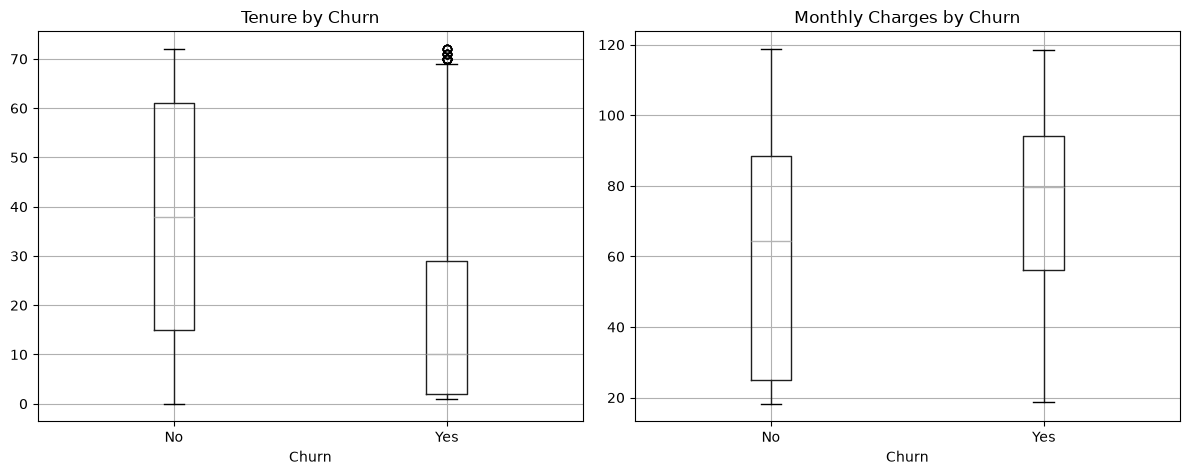

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(column="tenure", by="Churn", ax=axes[0])
axes[0].set_title("Tenure by Churn")

df.boxplot(column="MonthlyCharges", by="Churn", ax=axes[1])
axes[1].set_title("Monthly Charges by Churn")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [11]:
for col in ["Contract", "PaymentMethod", "InternetService"]:
    print(f"--- {col} ---")
    print((df.groupby(col)["Churn"].value_counts(normalize=True).unstack() * 100).round(1))
    print()

--- Contract ---
Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8

--- PaymentMethod ---
Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  83.3  16.7
Credit card (automatic)    84.8  15.2
Electronic check           54.7  45.3
Mailed check               80.9  19.1

--- InternetService ---
Churn              No   Yes
InternetService            
DSL              81.0  19.0
Fiber optic      58.1  41.9
No               92.6   7.4



In [12]:
for col in ["OnlineSecurity", "TechSupport", "OnlineBackup", "DeviceProtection"]:
    print(f"--- {col} ---")
    print((df.groupby(col)["Churn"].value_counts(normalize=True).unstack() * 100).round(1))
    print()

--- OnlineSecurity ---
Churn                  No   Yes
OnlineSecurity                 
No                   58.2  41.8
No internet service  92.6   7.4
Yes                  85.4  14.6

--- TechSupport ---
Churn                  No   Yes
TechSupport                    
No                   58.4  41.6
No internet service  92.6   7.4
Yes                  84.8  15.2

--- OnlineBackup ---
Churn                  No   Yes
OnlineBackup                   
No                   60.1  39.9
No internet service  92.6   7.4
Yes                  78.5  21.5

--- DeviceProtection ---
Churn                  No   Yes
DeviceProtection               
No                   60.9  39.1
No internet service  92.6   7.4
Yes                  77.5  22.5



In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (5634, 19) | Test: (1409, 19)


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier

numerical_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_cols = [c for c in X_train.columns if c not in numerical_cols]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

def make_model(n_neighbors=5, weights="uniform", p=2):
    return Pipeline([
        ("preprocess", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, p=p)),
    ])

In [15]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline = make_model(n_neighbors=5)
res = cross_validate(baseline, X_train, y_train, cv=cv, scoring=["accuracy", "precision", "recall", "f1", "roc_auc"])

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    print(f"{metric}: {res[f'test_{metric}'].mean():.4f} ± {res[f'test_{metric}'].std():.4f}")

c:\Users\Abdel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Abdel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_scorer.py", line 174, in __call__
    score = scorer._score(
        cached_call, estimator, *args, **routed_params.get(name).score
    )
  File "c:\Users\Abdel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_scorer.py", line 469, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Abdel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
  File "c:\Users\Abdel\AppData\Local\Prog

accuracy: 0.7654 ± 0.0050
precision: nan ± nan
recall: nan ± nan
f1: nan ± nan
roc_auc: 0.7820 ± 0.0052


c:\Users\Abdel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Abdel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_scorer.py", line 174, in __call__
    score = scorer._score(
        cached_call, estimator, *args, **routed_params.get(name).score
    )
  File "c:\Users\Abdel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_scorer.py", line 469, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Abdel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
  File "c:\Users\Abdel\AppData\Local\Prog

In [16]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, pos_label="Yes"),
    "recall": make_scorer(recall_score, pos_label="Yes"),
    "f1": make_scorer(f1_score, pos_label="Yes"),
    "roc_auc": "roc_auc",
}

baseline = make_model(n_neighbors=5)
res = cross_validate(baseline, X_train, y_train, cv=cv, scoring=scoring)

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    print(f"{metric}: {res[f'test_{metric}'].mean():.4f} ± {res[f'test_{metric}'].std():.4f}")

accuracy: 0.7654 ± 0.0050
precision: 0.5610 ± 0.0095
recall: 0.5324 ± 0.0198
f1: 0.5462 ± 0.0132
roc_auc: 0.7820 ± 0.0052


In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_neighbors": list(range(1, 31)),
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],
}

grid = GridSearchCV(
    make_model(), param_grid, cv=cv, scoring="roc_auc", n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

Best params: {'model__n_neighbors': 30, 'model__p': 2, 'model__weights': 'uniform'}
Best CV ROC-AUC: 0.8348949783855826


In [18]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

best_model = grid.best_estimator_
pred = best_model.predict(X_test)
proba = best_model.predict_proba(X_test)[:, 1]  # P(Yes)

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred, pos_label="Yes"))
print("Recall   :", recall_score(y_test, pred, pos_label="Yes"))
print("F1       :", f1_score(y_test, pred, pos_label="Yes"))
print("ROC-AUC  :", roc_auc_score(y_test, proba))
print("\nConfusion Matrix (rows=true, cols=pred, order=[No, Yes]):")
print(confusion_matrix(y_test, pred, labels=["No", "Yes"]))

Accuracy : 0.7877927608232789
Precision: 0.6112759643916914
Recall   : 0.5508021390374331
F1       : 0.5794655414908579
ROC-AUC  : 0.8310250846056472

Confusion Matrix (rows=true, cols=pred, order=[No, Yes]):
[[904 131]
 [168 206]]


In [19]:
import numpy as np

yt = y_test.values
rng = np.random.RandomState(42)
rows = []
for _ in range(1000):
    idx = rng.randint(0, len(yt), len(yt))
    if len(np.unique(yt[idx])) < 2:
        continue
    rows.append([
        accuracy_score(yt[idx], pred[idx]),
        precision_score(yt[idx], pred[idx], pos_label="Yes", zero_division=0),
        recall_score(yt[idx], pred[idx], pos_label="Yes", zero_division=0),
        roc_auc_score(yt[idx], proba[idx]),
    ])

ci = np.percentile(rows, [2.5, 97.5], axis=0)
for name, lo, hi in zip(["Accuracy", "Precision", "Recall", "ROC-AUC"], ci[0], ci[1]):
    print(f"{name}: 95% CI [{lo:.3f}, {hi:.3f}]")

Accuracy: 95% CI [0.769, 0.808]
Precision: 95% CI [0.560, 0.660]
Recall: 95% CI [0.505, 0.599]
ROC-AUC: 95% CI [0.809, 0.852]


In [20]:
test_df = X_test.copy()
test_df["y_true"] = y_test.values
test_df["y_pred"] = pred
test_df["proba"] = proba

fn = test_df[(test_df["y_true"] == "Yes") & (test_df["y_pred"] == "No")]
tp = test_df[(test_df["y_true"] == "Yes") & (test_df["y_pred"] == "Yes")]

print("False Negatives:", len(fn), "| True Positives:", len(tp))
print("\nFN vs TP averages:")
compare_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
print(pd.DataFrame({"FN mean": fn[compare_cols].mean(), "TP mean": tp[compare_cols].mean()}).round(2))

False Negatives: 168 | True Positives: 206

FN vs TP averages:
                FN mean  TP mean
tenure            24.65     9.78
MonthlyCharges    64.79    79.28
TotalCharges    2082.29   844.87


In [21]:
fp = test_df[(test_df["y_true"] == "No") & (test_df["y_pred"] == "Yes")]

print("False Negatives by Contract:")
print(fn["Contract"].value_counts(normalize=True) * 100)
print("\nFalse Positives by Contract:")
print(fp["Contract"].value_counts(normalize=True) * 100)

False Negatives by Contract:
Contract
Month-to-month    73.214286
One year          21.428571
Two year           5.357143
Name: proportion, dtype: float64

False Positives by Contract:
Contract
Month-to-month    96.183206
One year           3.053435
Two year           0.763359
Name: proportion, dtype: float64


In [22]:
import joblib
import os

os.makedirs("../models", exist_ok=True)
joblib.dump(best_model, "../models/knn_churn_pipeline.pkl")
print("Saved.")

reloaded = joblib.load("../models/knn_churn_pipeline.pkl")
print("Round trip OK:", np.allclose(reloaded.predict_proba(X_test)[:, 1], proba))

Saved.
Round trip OK: True
